## Section 0 — Rebuild TF-IDF
This section recreates the TF-IDF matrix from your cleaned text, which is the numerical foundation everything else in this notebook depends on. If you already ran this in the homework, you can skip it — but if your notebook restarted or lost its memory, run it again here. The max_features=500 argument limits the vocabulary to the 500 most common words, which keeps the math fast without losing much meaningful information.

Key vocab:

TF-IDF matrix — a giant table of numbers where every row is one of your documents and every column is a word. Each number represents how important that word is to that specific document.
Sparse matrix — a matrix where most values are zero. Your writing only uses a small fraction of all possible words, so most cells are empty.
max_features — a cap on how many unique words the vectorizer pays attention to. Words that appear very rarely across your writing get dropped.


## Section 1 — Elbow Method
Before you can cluster your writing, you have to decide how many clusters to create. The problem is there's no single right answer — you have to experiment. The elbow method helps by running K-Means with different values of k (2 clusters, 3 clusters, 4 clusters, all the way up to 9) and measuring how tightly packed the clusters are each time using a score called inertia. As you add more clusters, inertia always goes down — but at some point adding more clusters stops making a meaningful difference. That turning point in the graph, where the line bends and starts flattening out, is called the elbow. That's usually your best k.

Key vocab:

K-Means — a clustering algorithm that groups documents by similarity. You tell it how many groups (k) to make, and it figures out which documents belong together based on their word patterns.
Inertia — a measure of how spread out documents are within their clusters. Lower inertia means documents within a cluster are more similar to each other. Think of it as the "tightness" of your groups.
Elbow — the point on the inertia graph where adding more clusters stops helping much. It looks like a bent elbow in the curve.
k — the number of clusters you're asking K-Means to find. You choose this before running the algorithm.


## Section 2 — Run K-Means
Now that you have a sense of the right number of clusters from the elbow plot, this section actually runs K-Means with your chosen k and assigns every document in your writing to a cluster. The result gets saved as a new column in your dataframe called cluster, where each document gets a number (0, 1, 2, etc.) representing which group it landed in. These numbers don't have inherent meaning yet — Cluster 0 isn't "better" than Cluster 2. The numbers are just labels. Your job in the next sections is to figure out what each cluster actually represents.
Key vocab:

Cluster assignment — the group number that K-Means gives to each document. Documents with similar word patterns get the same number.
random_state — a setting that makes the algorithm produce the same result every time you run it. Without it, K-Means starts from a random position and might give slightly different results each run.
n_init — how many times K-Means restarts from a different random starting point. It then keeps the best result. Higher n_init = more reliable clusters.


## Section 3 — Top Words Per Cluster
This is the section that makes clustering actually meaningful. K-Means groups documents by word pattern similarity, but it doesn't tell you why it grouped them that way. This section does that by looking at the center of each cluster — a kind of "average document" — and finding the words that score highest there. Those words are what the cluster is most strongly defined by. After running this, your job is to look at the top words for each cluster and give it a human-readable name. For example, if Cluster 1's top words are "government, policy, economic, reform, political," you might name it "Political Writing." That act of naming is called interpretation, and it's something the machine genuinely cannot do for you.
Key vocab:

Cluster center (centroid) — the mathematical average of all the document vectors in a cluster. It represents the "typical" document for that group.
Top words — the words with the highest TF-IDF scores at the cluster center. These are the words most characteristic of that cluster's documents.
Interpretation — the human step of reading the top words and deciding what theme or topic they represent. This is where your judgment matters more than the algorithm's.


## Section 4 — Cluster Quality Metrics
Just because K-Means produced clusters doesn't mean those clusters are actually meaningful. This section gives you two mathematical ways to evaluate how good your clusters are, without needing any labels or outside information. The Silhouette Score measures how well each document fits its own cluster compared to neighboring clusters — a high score means documents are landing where they belong. The Davies-Bouldin Score measures how separated the clusters are from each other — a low score means your clusters are distinct and don't overlap much. You also look at cluster size here, because if one cluster has almost all the documents, your k might be too high or your writing might genuinely be dominated by one topic.
Key vocab:

Silhouette Score — ranges from -1 to +1. Above 0.5 is strong, 0.2–0.5 is reasonable, below 0.2 means the clusters are weak or overlapping.
Davies-Bouldin Score — ranges from 0 upward. Closer to 0 is better. It measures how similar each cluster is to its nearest neighboring cluster — you want clusters to be as different from each other as possible.
Unsupervised evaluation — measuring cluster quality without using labels. Since you never gave the algorithm the "right answer," you need different tools to assess whether its answer is any good.


## Section 5 — Sample Documents From Each Cluster
Metrics tell you whether the clusters are good. Reading actual examples tells you what they mean. This section prints a few real documents from each cluster so you can read them yourself and check whether the machine's groupings make intuitive sense. This is an important habit in data science — never trust a number without looking at the underlying data it came from. You might find that Cluster 0 is clearly all your science writing, or you might find a surprising document that ended up in the "wrong" cluster, which is worth investigating.
Key vocab:

Ground truth check — comparing a model's output to your own knowledge or judgment to see if the result makes sense. In this case, you already know your own writing, so you're the expert.
Misclassified document — a document that the algorithm placed in a cluster that doesn't seem to fit. This can reveal interesting edge cases or documents that genuinely blend multiple topics.


## Section 6 — PCA Scatter Plot
Your TF-IDF matrix has hundreds of dimensions — one for each word in your vocabulary. That's impossible to visualize directly because human eyes can only see 2 or 3 dimensions. PCA solves this by compressing all those dimensions down to just 2, while trying to preserve as much of the original structure as possible. Think of it like taking a 3D sculpture and casting a shadow onto a flat wall — you lose some information, but the shape is still recognizable. The resulting scatter plot shows each document as a dot, colored by its cluster assignment. Documents that are close together have similar word patterns. Documents that are far apart are very different from each other.
Key vocab:

PCA (Principal Component Analysis) — a technique for reducing the number of dimensions in a dataset while keeping as much meaningful structure as possible. It finds the directions in which your data varies the most and projects everything onto those axes.
Dimensionality reduction — the process of taking high-dimensional data (like a 500-word TF-IDF matrix) and compressing it into fewer dimensions for visualization or analysis.
Principal components — the new axes that PCA creates. They don't correspond to individual words — they're combinations of many words that together capture the most variation in your data.
Projection — placing high-dimensional points onto a lower-dimensional surface. Some information is lost, but the overall shape is preserved.


## Section 7 — Build Cosine Similarity Matrix
This section computes a similarity score between every pair of documents in your writing. The result is a square matrix where both the rows and columns represent your documents, and each cell contains a number between 0 and 1 telling you how similar those two documents are. A score of 1 means the documents use words in identical proportions. A score of 0 means they share no vocabulary at all. The diagonal is always 1.0 because every document is perfectly similar to itself.
Key vocab:

Cosine similarity — a measure of how similar two vectors are based on the angle between them rather than their size. Two documents pointing in the same direction in word-space are considered similar regardless of how long or short they are.
Similarity matrix — a square table where entry [i][j] tells you the cosine similarity between document i and document j. It's symmetric — the similarity from i to j is the same as from j to i.
Angle vs. distance — cosine similarity uses angle to measure similarity, not raw distance. This makes it length-independent, so a short paragraph and a long essay about the same topic can still score as very similar.


## Section 8 — Similarity Heatmap
A heatmap turns the similarity matrix into a color-coded image, which makes patterns much easier to spot than staring at a table of numbers. Each cell is colored by its similarity score — dark red means very similar, pale yellow means very different. If you see a bright red square in one corner of the heatmap, that means a group of documents all share very similar vocabulary. If the whole map is mostly pale yellow, your writing is highly varied. Bright spots off the diagonal are particularly interesting — they reveal pairs of documents that share strong word patterns even though they're far apart in your dataset.
Key vocab:

Heatmap — a visualization that uses color intensity to represent numerical values. Higher values get darker or brighter colors, making patterns visible at a glance.
Diagonal — in a similarity matrix, the diagonal runs from top-left to bottom-right and always contains 1.0, because every document is identical to itself. It shows up as a bright red line down the center of the heatmap.
Off-diagonal patterns — clusters of high similarity away from the diagonal. These reveal groups of documents that are unexpectedly similar to each other.


## Section 9 — Most and Least Similar Document Pairs
Rather than looking at the whole matrix at once, this section zooms in on the two most extreme cases: the pair of documents that are most similar to each other, and the pair that are most different. Finding these extremes is useful because they define the range of your writing. The most similar pair often reveals a topic you return to repeatedly, or a genre of writing where your style is very consistent. The least similar pair often reveals the two most opposite corners of your academic voice — perhaps a personal narrative and a technical lab report that barely share a word.
Key vocab:

Pairwise comparison — comparing every document to every other document and computing a score for each pair.
Argmax / Argmin — functions that find the index of the highest or lowest value in a matrix. argmax finds where the biggest number lives; argmin finds where the smallest number lives.
Fill diagonal — before searching for the most similar pair, we set the diagonal to 0 so the algorithm doesn't just return "document X is most similar to itself," which is trivially true and not useful.


## Section 10 — Find Most Similar Documents to a Given Document
This section lets you pick any document by its index number and see which other documents in your writing are most similar to it. This is the same logic behind recommendation systems — "you watched this movie, here are five more you might like." In your case: "you wrote this paragraph, here are the five most similar paragraphs elsewhere in your writing." It's a useful way to discover when you're returning to the same ideas or using the same framing across different assignments without realizing it.
Key vocab:

Query document — the document you're starting from. You're asking: "what is most similar to this?"
Ranked results — the output sorted from most to least similar. Rank 1 is the closest match, rank 2 is the second closest, and so on.
argsort — a function that returns the indices that would sort an array. We use it here to rank documents by their similarity score without actually rearranging the data.


## Section 11 — Search Your Own Writing With a New Query
This is where cosine similarity becomes genuinely useful as a tool. Instead of comparing existing documents to each other, you type any new sentence or phrase and the code finds the most similar passages in your own writing. This is exactly how search engines work at a conceptual level — your search query gets converted into a vector, and the engine finds documents whose vectors point in the same direction. The critical detail here is that we use transform() and not fit_transform() — because the new query has to be converted using the same vocabulary the vectorizer already learned from your writing. If you used fit_transform() it would try to learn a brand new vocabulary from just your one query sentence, which would break everything.
Key vocab:

Query vector — the numerical representation of your search phrase after it's been converted by the vectorizer.
transform() vs fit_transform() — fit_transform() learns a vocabulary AND converts text. transform() only converts text using a vocabulary it already learned. When searching with new text, always use transform() so the vocabulary stays consistent.
Semantic search — finding documents based on meaning and word overlap rather than exact keyword matching. If your query contains words that appear in a document, that document scores higher.


## Section 12 — Distribution of All Pairwise Similarity Scores
Rather than looking at individual pairs, this section zooms all the way out and looks at the full picture: what does the distribution of all similarity scores across all pairs of documents look like? A histogram skewed toward 0 means your writing is highly varied — most pairs of documents share very little vocabulary. A histogram with a peak closer to 0.5 or higher means your writing is quite consistent — the same words and ideas show up repeatedly across many different pieces. A bimodal distribution (two humps) is particularly interesting — it might mean you have two very distinct writing modes that rarely overlap.
Key vocab:

Distribution — the pattern of how values are spread out. A distribution tells you not just the average, but whether values are clustered tightly or spread widely.
Upper triangle — in a symmetric matrix like the similarity matrix, the values above the diagonal are identical to the values below it. By only looking at the upper triangle, we avoid counting each pair twice.
Bimodal distribution — a histogram with two peaks. In this context it would suggest two distinct clusters of similarity in your writing — some pairs that are very different and some that are very similar, with not much in between.

In [ ]:
# ============================================================
# FULL PIPELINE: K-MEANS CLUSTERING + COSINE SIMILARITY
# Starting point: you have df with 'clean_text' and tfidf_matrix
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# REBUILD TFIDF (skip if you already have tfidf_matrix + vectorizer)
# ============================================================

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()
print("TF-IDF matrix shape:", tfidf_matrix.shape)

# ============================================================
# SECTION 1: ELBOW METHOD — find the right number of clusters
# ============================================================

inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")

# ============================================================
# SECTION 2: RUN K-MEANS with your chosen number of clusters
# ============================================================

NUM_CLUSTERS = 3  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_

# ============================================================
# SECTION 3: TOP WORDS PER CLUSTER
# ============================================================

print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print("Your job: give this cluster a name based on these words!")
    print("-" * 40)

# ============================================================
# SECTION 4: CLUSTER METRICS
# ============================================================

sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")

# ============================================================
# SECTION 5: SAMPLE DOCUMENTS FROM EACH CLUSTER
# ============================================================

print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['clean_text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

# ============================================================
# SECTION 6: PCA SCATTER PLOT — visualize clusters in 2D
# ============================================================

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', '#f4a261']

plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

# ============================================================
# SECTION 7: BUILD COSINE SIMILARITY MATRIX
# ============================================================

similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")

# ============================================================
# SECTION 8: SIMILARITY HEATMAP
# ============================================================

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")

# ============================================================
# SECTION 9: MOST AND LEAST SIMILAR DOCUMENT PAIRS
# ============================================================

sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['clean_text'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['clean_text'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar?\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['clean_text'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['clean_text'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different?\n")

# ============================================================
# SECTION 10: FIND MOST SIMILAR DOCUMENTS TO A GIVEN DOCUMENT
# ============================================================

def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['clean_text'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['clean_text'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=0, similarity_matrix=similarity_matrix, df=df)

# ============================================================
# SECTION 11: SEARCH YOUR OWN WRITING WITH A NEW QUERY
# ============================================================

def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['clean_text'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="climate change and environmental policy",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

# ============================================================
# SECTION 12: DISTRIBUTION OF ALL PAIRWISE SIMILARITY SCORES
# ============================================================

upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied?")
print("  - Does this match your own sense of how diverse your topics are?")
print("  - Which pair surprised you most?")

# Work

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
# Load my writing and split into sentences
with open('AEFP.txt', 'r', encoding='utf-8') as f:
    raw_text = f.read().lstrip('\ufeff')

sentences = re.split(r'(?<=[.!?])\s+', raw_text)
sentences = [s.strip() for s in sentences if s.strip() and len(s.strip()) > 5]
print(f'Total sentences: {len(sentences)}')

# Clean each sentence
def clean(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cleaned_sentences = [clean(s) for s in sentences]

# Remove stop words with a for loop
stop_words = ENGLISH_STOP_WORDS
nostop_sentences = []
for sent in cleaned_sentences:
    kept = [w for w in sent.split() if w not in stop_words]
    nostop_sentences.append(' '.join(kept))

# Group every 10 sentences into one document
GROUP = 10
documents = []
for i in range(0, len(nostop_sentences), GROUP):
    documents.append(' '.join(nostop_sentences[i:i + GROUP]))

# Build df — one row per document (this is what the teacher's code expects)
df = pd.DataFrame({'clean_text': documents})
print(f'df has {len(df)} rows, each row = 1 document made of {GROUP} sentences')
df.head(3)

Total sentences: 1276
df has 128 rows, each row = 1 document made of 10 sentences


,clean_text
0,american dream sets just illusion drives hopef...
1,nick seeks uniformity new york instead spends ...
2,yale nick privy secret griefs wild page nick r...


In [16]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['clean_text'])
feature_names = vectorizer.get_feature_names_out()
print('TF-IDF matrix shape:', tfidf_matrix.shape)


TF-IDF matrix shape: (128, 4173)


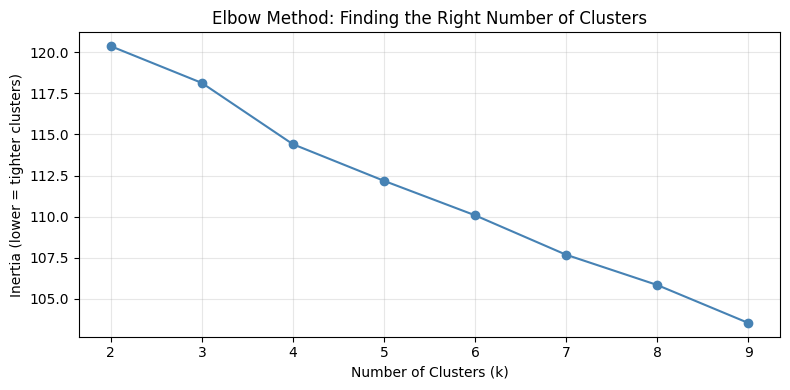

Look for the elbow — where the curve bends and flattens.
That k value is usually a good choice.



In [17]:
inertia_scores = []
cluster_range = range(2, 10)

for k in cluster_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(tfidf_matrix)
    inertia_scores.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia_scores, marker='o', color='steelblue')
plt.title('Elbow Method: Finding the Right Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.xticks(cluster_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Look for the elbow — where the curve bends and flattens.")
print("That k value is usually a good choice.\n")


In [18]:
NUM_CLUSTERS = 5  # change this after looking at the elbow plot

kmeans = KMeans(n_clusters=NUM_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(tfidf_matrix)
df['cluster'] = kmeans.labels_
df['cluster'].value_counts().sort_index()

cluster
0     8
1    30
2    27
3    55
4     8
Name: count, dtype: int64

In [19]:
print("=" * 50)
print("TOP WORDS PER CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    center = kmeans.cluster_centers_[cluster_num]
    top_word_indices = center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]
    doc_count = (df['cluster'] == cluster_num).sum()
    print(f"\nCluster {cluster_num} ({doc_count} documents)")
    print(f"Top words: {', '.join(top_words)}")
    print("Your job: give this cluster a name based on these words!")
    print("-" * 40)

TOP WORDS PER CLUSTER

Cluster 0 (8 documents)
Top words: veterans, vietnam, wwii, gi, era, war, integration, veteran, government, american
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 1 (30 documents)
Top words: sailing, regatta, results, improve, activity, happy, fun, sport, learned, learn
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 2 (27 documents)
Top words: narrator, macbeth, sonny, alan, macduff, blood, life, dysart, school, story
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 3 (55 documents)
Top words: argentina, united, christmas, states, lithium, people, enlightenment, scientific, world, church
Your job: give this cluster a name based on these words!
----------------------------------------

Cluster 4 (8 documents)
Top words: nick, gatsby, york, dream, pages, new, bancker, page, hope, novel
You

In [20]:
sil = silhouette_score(tfidf_matrix, df['cluster'])
db = davies_bouldin_score(tfidf_matrix.toarray(), df['cluster'])

print("\n" + "=" * 50)
print("CLUSTER QUALITY METRICS")
print("=" * 50)
print(f"\nSilhouette Score: {sil:.3f}")
print("  > 0.5 = strong clusters")
print("  0.2-0.5 = reasonable clusters")
print("  < 0.2 = weak or overlapping clusters")
print(f"\nDavies-Bouldin Score: {db:.3f}")
print("  Closer to 0 = better separated clusters")
print(f"\nDocuments per cluster:")
print(df['cluster'].value_counts().sort_index())
print("If one cluster has 90% of documents, try a different k\n")


CLUSTER QUALITY METRICS

Silhouette Score: 0.037
  > 0.5 = strong clusters
  0.2-0.5 = reasonable clusters
  < 0.2 = weak or overlapping clusters

Davies-Bouldin Score: 4.235
  Closer to 0 = better separated clusters

Documents per cluster:
cluster
0     8
1    30
2    27
3    55
4     8
Name: count, dtype: int64
If one cluster has 90% of documents, try a different k



In [21]:
print("=" * 50)
print("SAMPLE DOCUMENTS FROM EACH CLUSTER")
print("=" * 50)

for cluster_num in range(NUM_CLUSTERS):
    print(f"\n--- Cluster {cluster_num} ---")
    samples = df[df['cluster'] == cluster_num]['clean_text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"  [{i}] {text[:200]}...")

SAMPLE DOCUMENTS FROM EACH CLUSTER

--- Cluster 0 ---
  [1] additions arguments lepore blackhawk make historical narrative provide larger picture major events american history book ages rediscovery america leave reader questioning taught american history maybe...
  [2] wwi united states entered period economic depression veterans homeless jobless returning war fear similar issues following wwii harry w colmery drafted gi prevent depression gi aka servicemen s readju...
  [3] educationally wwii veterans little issue higher education government extremely focused preventing similar depression wwi wwii vietnam era veterans did receive attention public leading employment diffi...

--- Cluster 1 ---
  [1] barely communicative english taught dozens words like rake switch words thought simple completely foreign working nik felt like burden beginning constantly training machinery asked questions broken en...
  [2] additionally love variety global programs offered cox school business specificall

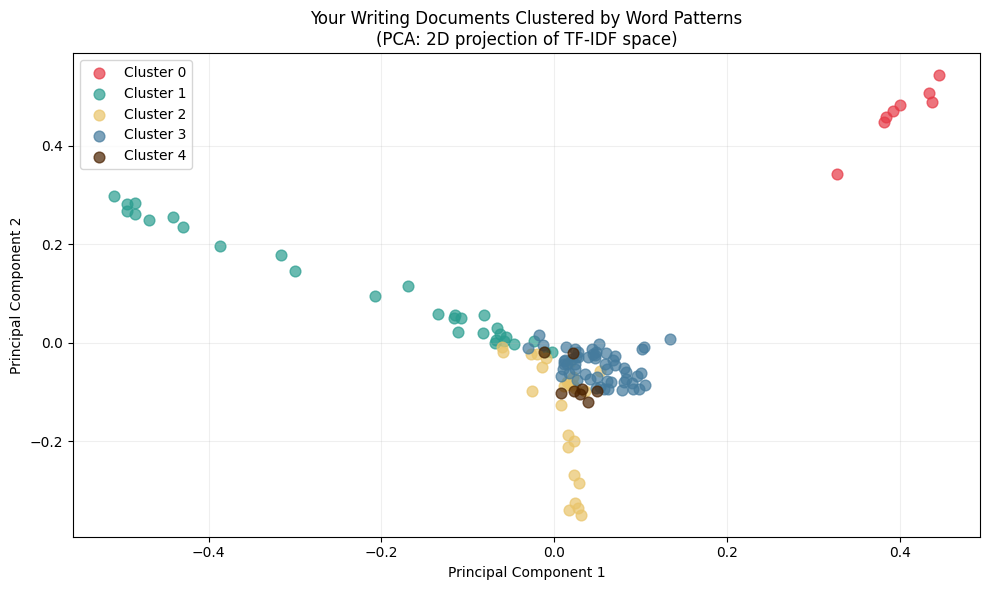

Each dot = one document. Dots close together = similar word patterns.



In [23]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

plot_df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'cluster': df['cluster'].astype(str)
})

colors = ['#e63946', '#2a9d8f', '#e9c46a', '#457b9d', "#4b2200"]

plt.figure(figsize=(10, 6))
for cluster_num in range(NUM_CLUSTERS):
    subset = plot_df[plot_df['cluster'] == str(cluster_num)]
    plt.scatter(subset['x'], subset['y'],
                label=f'Cluster {cluster_num}',
                alpha=0.7, s=60, color=colors[cluster_num])

plt.title('Your Writing Documents Clustered by Word Patterns\n(PCA: 2D projection of TF-IDF space)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
print("Each dot = one document. Dots close together = similar word patterns.\n")

In [24]:
similarity_matrix = cosine_similarity(tfidf_matrix)
print("Similarity matrix shape:", similarity_matrix.shape)
print(f"\nSample (first 4 documents vs first 4):")
print(np.round(similarity_matrix[:4, :4], 3))
print("Diagonal is always 1.0 — every document is identical to itself\n")

Similarity matrix shape: (128, 128)

Sample (first 4 documents vs first 4):
[[1.    0.399 0.392 0.358]
 [0.399 1.    0.45  0.389]
 [0.392 0.45  1.    0.383]
 [0.358 0.389 0.383 1.   ]]
Diagonal is always 1.0 — every document is identical to itself



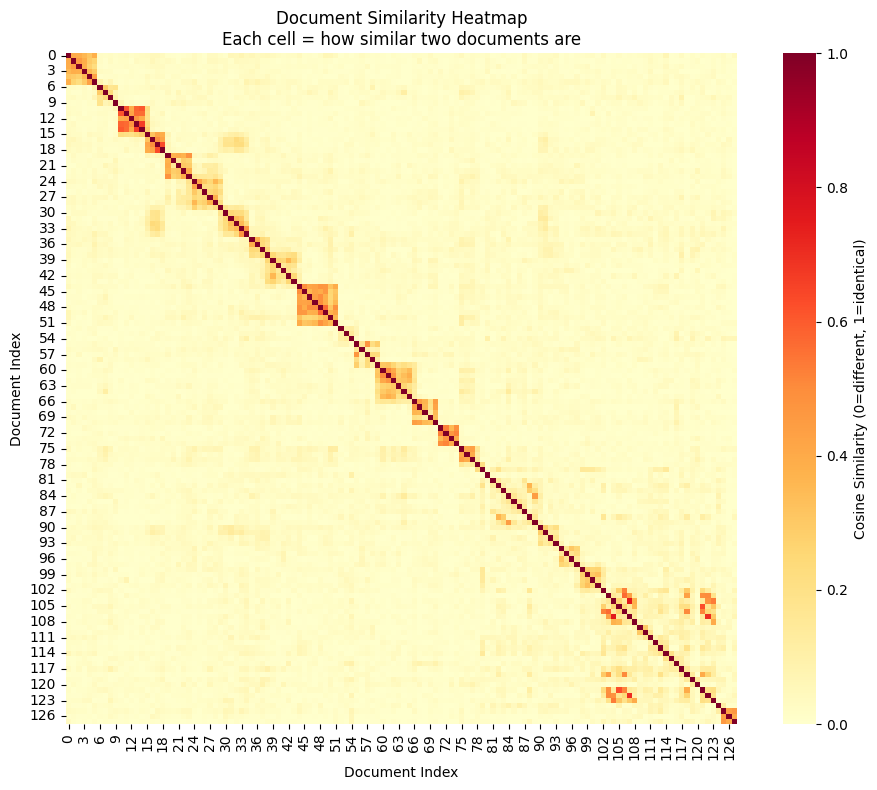

Bright red = very similar. Pale yellow = very different.



In [25]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, cmap='YlOrRd', vmin=0, vmax=1,
            square=True,
            cbar_kws={'label': 'Cosine Similarity (0=different, 1=identical)'})
plt.title('Document Similarity Heatmap\nEach cell = how similar two documents are')
plt.xlabel('Document Index')
plt.ylabel('Document Index')
plt.tight_layout()
plt.show()
print("Bright red = very similar. Pale yellow = very different.\n")

In [26]:
sim_no_diagonal = similarity_matrix.copy()
np.fill_diagonal(sim_no_diagonal, 0)

most_similar_idx = np.unravel_index(np.argmax(sim_no_diagonal), sim_no_diagonal.shape)
doc_a, doc_b = most_similar_idx

sim_find_low = similarity_matrix.copy()
np.fill_diagonal(sim_find_low, 1)
least_similar_idx = np.unravel_index(np.argmin(sim_find_low), sim_find_low.shape)
doc_c, doc_d = least_similar_idx

print("=" * 50)
print("YOUR MOST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_a][doc_b]:.3f}")
print(f"\nDocument {doc_a}:\n  {df['clean_text'].iloc[doc_a][:300]}...")
print(f"\nDocument {doc_b}:\n  {df['clean_text'].iloc[doc_b][:300]}...")
print("\nQuestion: why do you think these two are so similar?\n")

print("=" * 50)
print("YOUR LEAST SIMILAR DOCUMENT PAIR")
print("=" * 50)
print(f"Score: {similarity_matrix[doc_c][doc_d]:.3f}")
print(f"\nDocument {doc_c}:\n  {df['clean_text'].iloc[doc_c][:300]}...")
print(f"\nDocument {doc_d}:\n  {df['clean_text'].iloc[doc_d][:300]}...")
print("\nQuestion: what makes these two so different?\n")


YOUR MOST SIMILAR DOCUMENT PAIR
Score: 0.751

Document 104:
  learned appreciate sport instead just winning learned lose enjoy practicing sailing activity sport video game instrument time face challenge strongly believe realization positive effect future pursue activity knowing winning happy matter long like doing good bad help future learn lose learn improve ...

Document 107:
  realized winning results process practicing having fun results aren t wanted doesn t matter long enjoyed getting learned appreciate sport instead just winning learned lose enjoy practicing sailing activity sport video game instrument time face challenge strongly believe realization positive effect f...

Question: why do you think these two are so similar?

YOUR LEAST SIMILAR DOCUMENT PAIR
Score: 0.000

Document 1:
  nick seeks uniformity new york instead spends summer outgoing people going outlandish excursions later gatsby s party chapter nick s opinions change excited triumph glide sea change faces voices co

the most similar pairs are very close in doc number so I assume they came fron the same piece of writing which looks like one of my eighth grade essays for boarding school applications, the least similar documents are about two entirely different topics. one is the great gatsby and the other is a research paper about vietnam vets

In [27]:
def find_most_similar(doc_index, similarity_matrix, df, top_n=5):
    scores = similarity_matrix[doc_index]
    sorted_indices = scores.argsort()[::-1]
    similar_indices = [i for i in sorted_indices if i != doc_index][:top_n]

    print(f"Source document [{doc_index}]:")
    print(f"  {df['clean_text'].iloc[doc_index][:250]}...\n")
    print(f"Top {top_n} most similar documents:\n")

    for rank, idx in enumerate(similar_indices, 1):
        print(f"  [{rank}] Similarity: {scores[idx]:.3f}")
        print(f"       {df['clean_text'].iloc[idx][:200]}...")
        print()

find_most_similar(doc_index=0, similarity_matrix=similarity_matrix, df=df)


Source document [0]:
  american dream sets just illusion drives hopeful insane characters great gatsby drawn new york promises money connections love regardless differences character common drive insane whilst chasing unattainable fantasy chapters novel make claim obvious ...

Top 5 most similar documents:

  [1] Similarity: 0.399
       nick seeks uniformity new york instead spends summer outgoing people going outlandish excursions later gatsby s party chapter nick s opinions change excited triumph glide sea change faces voices color...

  [2] Similarity: 0.392
       yale nick privy secret griefs wild page nick refers past new york attended yale nick describes peers outlandish nature connotated wild passage carries tone superiority nick indicates reader quickly kn...

  [3] Similarity: 0.381
       gatsby s belief green light connects hope pages eventually drove death pursuit dream conclusion nnovels inferred based key details chapter case great gatsby foreshadow nick gatsby s belief

In [28]:
def search_my_writing(query_text, vectorizer, tfidf_matrix, df, top_n=5):
    # transform() uses the existing vocabulary — NOT fit_transform()
    # fit_transform() would learn a new vocabulary from your query alone
    query_vector = vectorizer.transform([query_text])
    query_similarities = cosine_similarity(query_vector, tfidf_matrix)[0]
    top_indices = query_similarities.argsort()[::-1][:top_n]

    print(f"Query: '{query_text}'")
    print(f"\nMost similar passages in your writing:\n")

    for rank, idx in enumerate(top_indices, 1):
        score = query_similarities[idx]
        if score == 0:
            print(f"  [{rank}] No similarity found (score: 0.000)")
            print(f"       This word may not be in your writing vocabulary")
        else:
            print(f"  [{rank}] Similarity: {score:.3f}")
            print(f"       {df['clean_text'].iloc[idx][:250]}...")
        print()

# Change this query to anything you want to search for in your writing
search_my_writing(
    query_text="climate change and environmental policy",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df
)

Query: 'climate change and environmental policy'

Most similar passages in your writing:

  [1] Similarity: 0.109
       working group students government excited computer science began built pc covid increased built friends faced seemingly infinite software issues recently signed online computer science course brilliant org website emphasizes problem solving user enga...

  [2] Similarity: 0.103
       problems argentina create unreliable environmentally damaging supply chain easily seized competitors united states aim avoid structure using dime formulate healthy lithium partnership argentina diplomatically united states respectfully closer argenti...

  [3] Similarity: 0.076
       need coerce deter additionally display military power relation lithium mining aggravate competitors increase tensions number lithium importers exporters militarily united states policy focus quiet protection argentine mining sites attacks physical cy...

  [4] Similarity: 0.075
       policy documents unit

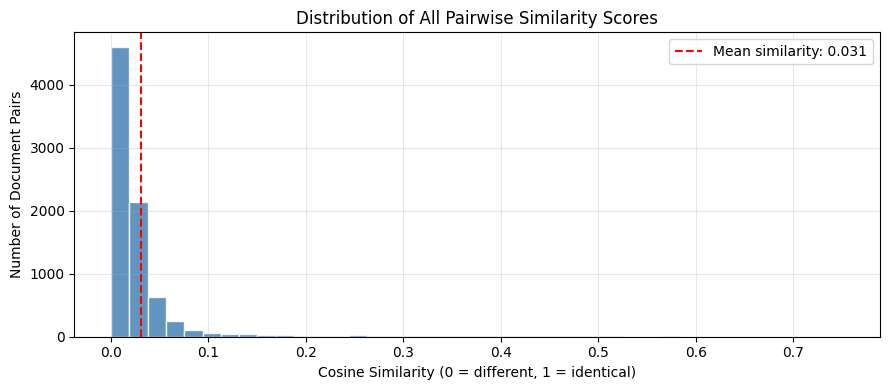

Average similarity across all pairs: 0.031
Most similar pair:  0.751
Least similar pair: 0.000

Reflection questions:
  - Is your writing more similar overall, or more varied?
  - Does this match your own sense of how diverse your topics are?
  - Which pair surprised you most?


In [29]:
upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
all_pair_scores = similarity_matrix[upper_triangle_indices]

plt.figure(figsize=(9, 4))
plt.hist(all_pair_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_pair_scores), color='red', linestyle='--',
            label=f'Mean similarity: {np.mean(all_pair_scores):.3f}')
plt.title('Distribution of All Pairwise Similarity Scores')
plt.xlabel('Cosine Similarity (0 = different, 1 = identical)')
plt.ylabel('Number of Document Pairs')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Average similarity across all pairs: {np.mean(all_pair_scores):.3f}")
print(f"Most similar pair:  {np.max(all_pair_scores):.3f}")
print(f"Least similar pair: {np.min(all_pair_scores):.3f}")
print()
print("Reflection questions:")
print("  - Is your writing more similar overall, or more varied?")
print("  - Does this match your own sense of how diverse your topics are?")
print("  - Which pair surprised you most?")

it looks like my writing overall is pretty varied, most similarity scores lie below 0.1. I think my writing style is always similar but I have written a wide variety of essays over the past 4+ years so it makes sense. I dont think any pair really surprised me.